Baseline and Feasibility study for research

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.7 MB/s eta 0:00:00


In [3]:
import os
import time
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim
import lpips

# Use same setup from Part 3B
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

import warnings
warnings.filterwarnings('ignore')

Device: cuda


In [4]:
# Paths from Part 3B
EXPERIMENT_DIR = "/content/drive/MyDrive/multi_restoration_FIXED"
CHECKPOINT_DIR = os.path.join(EXPERIMENT_DIR, "checkpoints")
TEST_CLEAN = "/content/drive/MyDrive/celeba_hq_splits/test/clean"
MULTI_DEG_ROOT = "/content/drive/MyDrive/celeba_hq_multi_degraded_FIXED"

# Part 5 specific paths
COMPARISON_DIR = os.path.join(EXPERIMENT_DIR, "part5_comparison")
os.makedirs(COMPARISON_DIR, exist_ok=True)

IMG_SIZE = 128
print(f"Results will be saved to: {COMPARISON_DIR}")


Results will be saved to: /content/drive/MyDrive/multi_restoration_FIXED/part5_comparison


In [6]:
# ======================
# CELL 2: Load Your Multi-Task Model from Part 3B
# ======================
from basicsr.archs.rrdbnet_arch import RRDBNet

class MultiRestorationModel(nn.Module):
    """Your multi-task model from Part 3B"""
    def __init__(self, num_degradations=5, base_channels=64, num_blocks=16):
        super().__init__()
        self.encoder = RRDBNet(
            num_in_ch=3, num_out_ch=base_channels,
            num_feat=base_channels, num_block=num_blocks,
            num_grow_ch=32, scale=1
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(base_channels, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_degradations)
        )
        self.restoration_heads = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(base_channels, base_channels, 3, 1, 1), nn.ReLU(),
                nn.Conv2d(base_channels, 3, 3, 1, 1), nn.Sigmoid()
            ) for _ in range(num_degradations)
        ])
        self.fusion = nn.Sequential(
            nn.Conv2d(base_channels + 3, base_channels, 1), nn.ReLU(),
            nn.Conv2d(base_channels, 3, 1), nn.Sigmoid()
        )

    def forward(self, x, deg_type=None):
        features = self.encoder(x)
        deg_logits = self.classifier(features)
        if self.training or deg_type is None:
            restored_outputs = [head(features) for head in self.restoration_heads]
            deg_probs = F.softmax(deg_logits, dim=1)
            stacked = torch.stack(restored_outputs, dim=1)
            weighted = (stacked * deg_probs.view(-1, 5, 1, 1, 1)).sum(dim=1)
            combined = torch.cat([features, x], dim=1)
            final_output = self.fusion(combined)
            return final_output, deg_logits
        else:
            restored = self.restoration_heads[deg_type](features)
            combined = torch.cat([features, x], dim=1)
            final_output = self.fusion(combined)
            return final_output, deg_logits

print("\n Loading your trained multi-task model:")
your_model = MultiRestorationModel().to(DEVICE)
model_path = os.path.join(CHECKPOINT_DIR, "best_multi_model_FIXED.pth")
your_model.load_state_dict(torch.load(model_path, map_location=DEVICE)['model_state'])
your_model.eval()
print(f"Model loaded from: {model_path}")



 Loading your trained multi-task model:
Model loaded from: /content/drive/MyDrive/multi_restoration_FIXED/checkpoints/best_multi_model_FIXED.pth


In [7]:
!pip install bm3d         # For BM3D baseline
!pip install thop    # calculation of flop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 20.1 MB/s eta 0:00:00


In [8]:
# ======================
# CELL 3: BASELINE 1 - BM3D Implementation
# ======================
def apply_bm3d(degraded_np):
    try:
        import bm3d
        # Convert to [0,1] float
        img = degraded_np.astype(np.float32) / 255.0
        denoised = bm3d.bm3d(img, sigma_psd=25/255.0, stage_arg=bm3d.BM3DStages.ALL_STAGES)
        return (np.clip(denoised, 0, 1) * 255).astype(np.uint8)
    except ImportError:
        print("BM3D not installed. Using OpenCV Non-Local Means instead.")
        print("Install with: pip install bm3d")
        # Fallback: OpenCV denoising
        return cv2.fastNlMeansDenoisingColored(degraded_np, None, 10, 10, 7, 21)

print("BM3D baseline ready")

BM3D baseline ready


In [9]:
# ======================
# CELL 4: BASELINE 2 - AirNet Architecture
# ======================

class AirNetBaseline(nn.Module):
    def __init__(self, base_channels=80, num_blocks=20):
        super().__init__()

        # Encoder path (3 scales)
        self.enc1 = self._make_layer(3, base_channels, num_blocks//3)
        self.down1 = nn.Conv2d(base_channels, base_channels, 3, 2, 1)

        self.enc2 = self._make_layer(base_channels, base_channels*2, num_blocks//3)
        self.down2 = nn.Conv2d(base_channels*2, base_channels*2, 3, 2, 1)

        self.enc3 = self._make_layer(base_channels*2, base_channels*4, num_blocks//3)

        # Bottleneck
        self.bottleneck = self._make_layer(base_channels*4, base_channels*4, 4)

        # Decoder path
        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, 2)
        self.dec2 = self._make_layer(base_channels*4, base_channels*2, num_blocks//3)

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, 2)
        self.dec1 = self._make_layer(base_channels*2, base_channels, num_blocks//3)

        # Output
        self.out = nn.Sequential(
            nn.Conv2d(base_channels, 3, 3, 1, 1),
            nn.Sigmoid()
        )

    def _make_layer(self, in_ch, out_ch, num_blocks):
        layers = [nn.Conv2d(in_ch, out_ch, 3, 1, 1), nn.ReLU()]
        for _ in range(num_blocks - 1):
            layers += [nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.ReLU()]
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        e3 = self.enc3(self.down2(e2))

        # Bottleneck
        b = self.bottleneck(e3)

        # Decoder with skip connections
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

airnet_model = AirNetBaseline(base_channels=80, num_blocks=20).to(DEVICE)
airnet_model.eval()
print("AirNet baseline initialized (random weights)")

AirNet baseline initialized (random weights)


In [10]:
# ======================
# CELL 5: Test Dataset Loader
# ======================
class SimpleTestDataset(torch.utils.data.Dataset):
    def __init__(self, clean_dir, multi_deg_root, deg_type='combined', img_size=128):
        self.clean_dir = Path(clean_dir)
        self.deg_dir = Path(multi_deg_root) / 'test' / deg_type
        self.img_size = img_size

        # Get all test files
        self.files = sorted([f.name for f in self.deg_dir.iterdir()
                           if f.suffix.lower() in ('.jpg', '.png', '.jpeg')])

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        clean_path = self.clean_dir / fname
        deg_path = self.deg_dir / fname

        clean = Image.open(clean_path).convert('RGB')
        degraded = Image.open(deg_path).convert('RGB')

        clean_t = self.transform(clean)
        deg_t = self.transform(degraded)

        return deg_t, clean_t, fname

print("\nCreating test dataset (using 'combined' degradation for fair comparison)...")
test_ds = SimpleTestDataset(TEST_CLEAN, MULTI_DEG_ROOT, deg_type='combined', img_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)
print(f"Test dataset: {len(test_ds)} images")


Creating test dataset (using 'combined' degradation for fair comparison)...
Test dataset: 3000 images


In [11]:
# ======================
# CELL 6: Computational Feasibility Analysis
# ======================
def analyze_computational_feasibility(model, model_name, input_size=(1, 3, 128, 128), device='cuda'):

    model = model.to(device).eval()
    dummy_input = torch.randn(input_size).to(device)

    results = {'model_name': model_name}

    # 1. Parameter Count
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    results['params_total'] = total_params
    results['params_total_M'] = total_params / 1e6
    results['params_trainable_M'] = trainable_params / 1e6

    print(f"\nParameters:")
    print(f"Total: {total_params:,} ({total_params/1e6:.2f}M)")
    print(f"Trainable: {trainable_params:,} ({trainable_params/1e6:.2f}M)")

    # 2. FLOPs
    try:
        from thop import profile
        flops, _ = profile(model, inputs=(dummy_input,), verbose=False)
        results['flops'] = flops
        results['flops_G'] = flops / 1e9
        print(f"\nFLOPs:")
        print(f"   {flops:,} ({flops/1e9:.2f}G)")
    except ImportError:
        print(f"\nFLOPs: N/A (install thop: pip install thop)")
        results['flops_G'] = 'N/A'
    except Exception as e:
        print(f"\nFLOPs: Calculation failed")
        results['flops_G'] = 'N/A'

    # 3. Inference Speed
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Warmup
    with torch.no_grad():
        for _ in range(10):
            if isinstance(model, AirNetBaseline):
                _ = model(dummy_input)
            else:
                _ = model(dummy_input)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Measure
    start = time.time()
    with torch.no_grad():
        for _ in range(100):
            if isinstance(model, AirNetBaseline):
                _ = model(dummy_input)
            else:
                _ = model(dummy_input)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    elapsed = time.time() - start
    avg_time = elapsed / 100

    results['inference_time_s'] = avg_time
    results['inference_time_ms'] = avg_time * 1000
    results['fps'] = 1 / avg_time

    print(f"\n Inference Speed:")
    print(f"   Time: {avg_time*1000:.2f} ms/image")
    print(f"   FPS: {1/avg_time:.2f}")

    # 4. Memory Usage
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            if isinstance(model, AirNetBaseline):
                _ = model(dummy_input)
            else:
                _ = model(dummy_input)

        memory_bytes = torch.cuda.max_memory_allocated()
        results['memory_bytes'] = memory_bytes
        results['memory_MB'] = memory_bytes / 1024**2
        results['memory_GB'] = memory_bytes / 1024**3

        print(f"\n GPU Memory:")
        print(f"   {memory_bytes/1024**2:.2f} MB ({memory_bytes/1024**3:.3f} GB)")
    else:
        results['memory_MB'] = 'N/A'
        print(f"\n Memory: N/A (CPU mode)")

    # 5. Model Size
    import tempfile
    with tempfile.NamedTemporaryFile(delete=True, suffix='.pth') as tmp:
        torch.save(model.state_dict(), tmp.name)
        size_bytes = Path(tmp.name).stat().st_size
        results['model_size_bytes'] = size_bytes
        results['model_size_MB'] = size_bytes / 1024**2
        print(f"\nMod el Size (saved):")
        print(f"   {size_bytes/1024**2:.2f} MB")

    print(f"{'='*70}\n")

    return results


In [12]:
# ======================
# CELL 7: Performance Evaluation
# ======================
def evaluate_model_performance(model, test_loader, device, model_name, is_bm3d=False):
    print(f"\n{'='*70}")
    print(f"PERFORMANCE EVALUATION: {model_name}")
    print(f"{'='*70}")

    # Initialize LPIPS
    lpips_fn = lpips.LPIPS(net='alex', verbose=False).to(device).eval()

    if not is_bm3d:
        model.eval()

    psnr_list = []
    ssim_list = []
    lpips_list = []
    inference_times = []

    with torch.no_grad():
        for degraded, clean, fname in tqdm(test_loader, desc=f"Testing {model_name}"):

            if not is_bm3d:
                degraded = degraded.to(device)
                clean = clean.to(device)

                start = time.time()
                if isinstance(model, AirNetBaseline):
                    restored = model(degraded)
                else:
                    restored, _ = model(degraded)
                inference_times.append(time.time() - start)

                # To numpy
                restored_np = (restored[0].cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)
                clean_np = (clean[0].cpu().permute(1,2,0).numpy() * 255).astype(np.uint8)

                # LPIPS
                lpips_val = lpips_fn(clean, restored).item()
                lpips_list.append(lpips_val)

            else:  # BM3D
                degraded_np = (degraded[0].permute(1,2,0).numpy() * 255).astype(np.uint8)
                clean_np = (clean[0].permute(1,2,0).numpy() * 255).astype(np.uint8)

                start = time.time()
                restored_np = apply_bm3d(degraded_np)
                inference_times.append(time.time() - start)

            # Calculate metrics
            psnr_val = sk_psnr(clean_np, restored_np, data_range=255)
            ssim_val = sk_ssim(clean_np, restored_np, multichannel=True, channel_axis=2, data_range=255)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

    # Aggregate results
    results = {
        'model_name': model_name,
        'psnr_mean': np.mean(psnr_list),
        'psnr_std': np.std(psnr_list),
        'ssim_mean': np.mean(ssim_list),
        'ssim_std': np.std(ssim_list),
        'lpips_mean': np.mean(lpips_list) if lpips_list else None,
        'lpips_std': np.std(lpips_list) if lpips_list else None,
        'inference_time_ms': np.mean(inference_times) * 1000,
        'fps': 1 / np.mean(inference_times),
    }

    print(f"\n Results Summary:")
    print(f"   PSNR: {results['psnr_mean']:.2f} ± {results['psnr_std']:.2f} dB")
    print(f"   SSIM: {results['ssim_mean']:.4f} ± {results['ssim_std']:.4f}")
    if results['lpips_mean']:
        print(f"   LPIPS: {results['lpips_mean']:.4f} ± {results['lpips_std']:.4f}")
    print(f"   Speed: {results['inference_time_ms']:.2f} ms ({results['fps']:.1f} FPS)")
    print(f"{'='*70}\n")

    return results


In [13]:
all_results = {}

# ==========================================
# 1. YOUR MULTI-TASK MODEL
# ==========================================
print("\n" + "="*70)
print("MODEL 1:MULTI-TASK RESTORATION MODEL-3B")
print("="*70)

# Computational analysis
your_comp = analyze_computational_feasibility(your_model, "Your Multi-Task Model", device=DEVICE)

# Performance evaluation
your_perf = evaluate_model_performance(your_model, test_loader, DEVICE, "Your Multi-Task Model")

all_results['your_model'] = {**your_comp, **your_perf}


MODEL 1:MULTI-TASK RESTORATION MODEL-3B

Parameters:
Total: 11,929,943 (11.93M)
Trainable: 11,929,943 (11.93M)

FLOPs:
   17,042,514,624.0 (17.04G)

 Inference Speed:
   Time: 25.89 ms/image
   FPS: 38.62

 GPU Memory:
   123.34 MB (0.120 GB)

Mod el Size (saved):
   45.73 MB


PERFORMANCE EVALUATION: Your Multi-Task Model
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 189MB/s]


Testing Your Multi-Task Model:   0%|          | 0/3000 [00:00<?, ?it/s]


 Results Summary:
   PSNR: 25.44 ± 1.73 dB
   SSIM: 0.8111 ± 0.0381
   LPIPS: 0.1678 ± 0.0434
   Speed: 30.16 ms (33.2 FPS)



In [14]:
# ==========================================
# 2. BASELINE 1: BM3D
# ==========================================
print("\n" + "="*70)
print("BASELINE 1: BM3D (CLASSICAL)")
print("="*70)

bm3d_perf = evaluate_model_performance(None, test_loader, DEVICE, "BM3D", is_bm3d=True)

all_results['bm3d'] = {
    'model_name': 'BM3D',
    'params_total_M': 0,
    'flops_G': 0,
    'model_size_MB': 0,
    'memory_MB': 'N/A',
    'note': 'Classical algorithm (no trainable parameters)',
    **bm3d_perf
}



BASELINE 1: BM3D (CLASSICAL)

PERFORMANCE EVALUATION: BM3D


Testing BM3D:   0%|          | 0/3000 [00:00<?, ?it/s]


 Results Summary:
   PSNR: 15.92 ± 3.51 dB
   SSIM: 0.6868 ± 0.0946
   Speed: 4107.38 ms (0.2 FPS)



In [15]:
# ==========================================
# 3. BASELINE 2: AirNet
# ==========================================
print("\n" + "="*70)
print("BASELINE 2: AirNet (DEEP LEARNING)")
print("="*70)

# Computational analysis
airnet_comp = analyze_computational_feasibility(airnet_model, "AirNet", device=DEVICE)

# Performance evaluation
airnet_perf = evaluate_model_performance(airnet_model, test_loader, DEVICE, "AirNet (Untrained)")
airnet_perf['note'] = 'Random initialization (architecture comparison only)'

all_results['airnet'] = {**airnet_comp, **airnet_perf}



BASELINE 2: AirNet (DEEP LEARNING)

Parameters:
Total: 12,881,283 (12.88M)
Trainable: 12,881,283 (12.88M)

FLOPs:
   34,306,785,280.0 (34.31G)

 Inference Speed:
   Time: 13.67 ms/image
   FPS: 73.15

 GPU Memory:
   138.10 MB (0.135 GB)

Mod el Size (saved):
   49.17 MB


PERFORMANCE EVALUATION: AirNet (Untrained)


Testing AirNet (Untrained):   0%|          | 0/3000 [00:00<?, ?it/s]


 Results Summary:
   PSNR: 10.93 ± 1.46 dB
   SSIM: 0.2663 ± 0.0753
   LPIPS: 0.6870 ± 0.0311
   Speed: 6.65 ms (150.3 FPS)



In [16]:
# Save JSON
with open(os.path.join(COMPARISON_DIR, 'comparison_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"✓ Results saved to: {os.path.join(COMPARISON_DIR, 'comparison_results.json')}")


✓ Results saved to: /content/drive/MyDrive/multi_restoration_FIXED/part5_comparison/comparison_results.json


In [19]:
# ======================
# CELL 10: Print Comparison Tables
# ======================
print("\n" + "="*70)
print("📊 FINAL COMPARISON TABLES")
print("="*70)

print("\n" + "="*100)
print("TABLE 1: IMAGE QUALITY METRICS")
print("="*100)
print(f"{'Model':<30} {'PSNR (dB)':<20} {'SSIM':<20} {'LPIPS':<20}")
print("-"*100)

for key in ['your_model', 'bm3d', 'airnet']:
    res = all_results[key]
    model_name = res['model_name']
    psnr_str = f"{res['psnr_mean']:.2f} ± {res['psnr_std']:.2f}"
    ssim_str = f"{res['ssim_mean']:.4f} ± {res['ssim_std']:.4f}"
    lpips_str = f"{res['lpips_mean']:.4f} ± {res['lpips_std']:.4f}" if res.get('lpips_mean') else "N/A"

    print(f"{model_name:<30} {psnr_str:<20} {ssim_str:<20} {lpips_str:<20}")

print("="*100)

print("\n" + "="*120)
print("TABLE 2: COMPUTATIONAL EFFICIENCY")
print("="*120)
print(f"{'Model':<30} {'Params (M)':<15} {'FLOPs (G)':<15} {'Speed (ms)':<15} {'FPS':<15} {'Memory (MB)':<15}")
print("-"*120)

for key in ['your_model', 'bm3d', 'airnet']:
    res = all_results[key]
    model_name = res['model_name']

    params_str = f"{res.get('params_total_M', 0):.2f}"
    flops_str = f"{res.get('flops_G', 0):.2f}" if isinstance(res.get('flops_G'), (int, float)) else "N/A"
    speed_str = f"{res['inference_time_ms']:.2f}"
    fps_str = f"{res['fps']:.2f}"
    memory_str = f"{res.get('memory_MB', 'N/A'):.2f}" if isinstance(res.get('memory_MB'), (int, float)) else "N/A"

    print(f"{model_name:<30} {params_str:<15} {flops_str:<15} {speed_str:<15} {fps_str:<15} {memory_str:<15}")

print("="*120)


📊 FINAL COMPARISON TABLES

TABLE 1: IMAGE QUALITY METRICS
Model                          PSNR (dB)            SSIM                 LPIPS               
----------------------------------------------------------------------------------------------------
Your Multi-Task Model          25.44 ± 1.73         0.8111 ± 0.0381      0.1678 ± 0.0434     
BM3D                           15.92 ± 3.51         0.6868 ± 0.0946      N/A                 
AirNet (Untrained)             10.93 ± 1.46         0.2663 ± 0.0753      0.6870 ± 0.0311     

TABLE 2: COMPUTATIONAL EFFICIENCY
Model                          Params (M)      FLOPs (G)       Speed (ms)      FPS             Memory (MB)    
------------------------------------------------------------------------------------------------------------------------
Your Multi-Task Model          11.93           17.04           30.16           33.15           123.34         
BM3D                           0.00            0.00            4107.38         0.24   


 Creating visualization plots...
Visualization saved to: /content/drive/MyDrive/multi_restoration_FIXED/part5_comparison/baseline_comparison.png


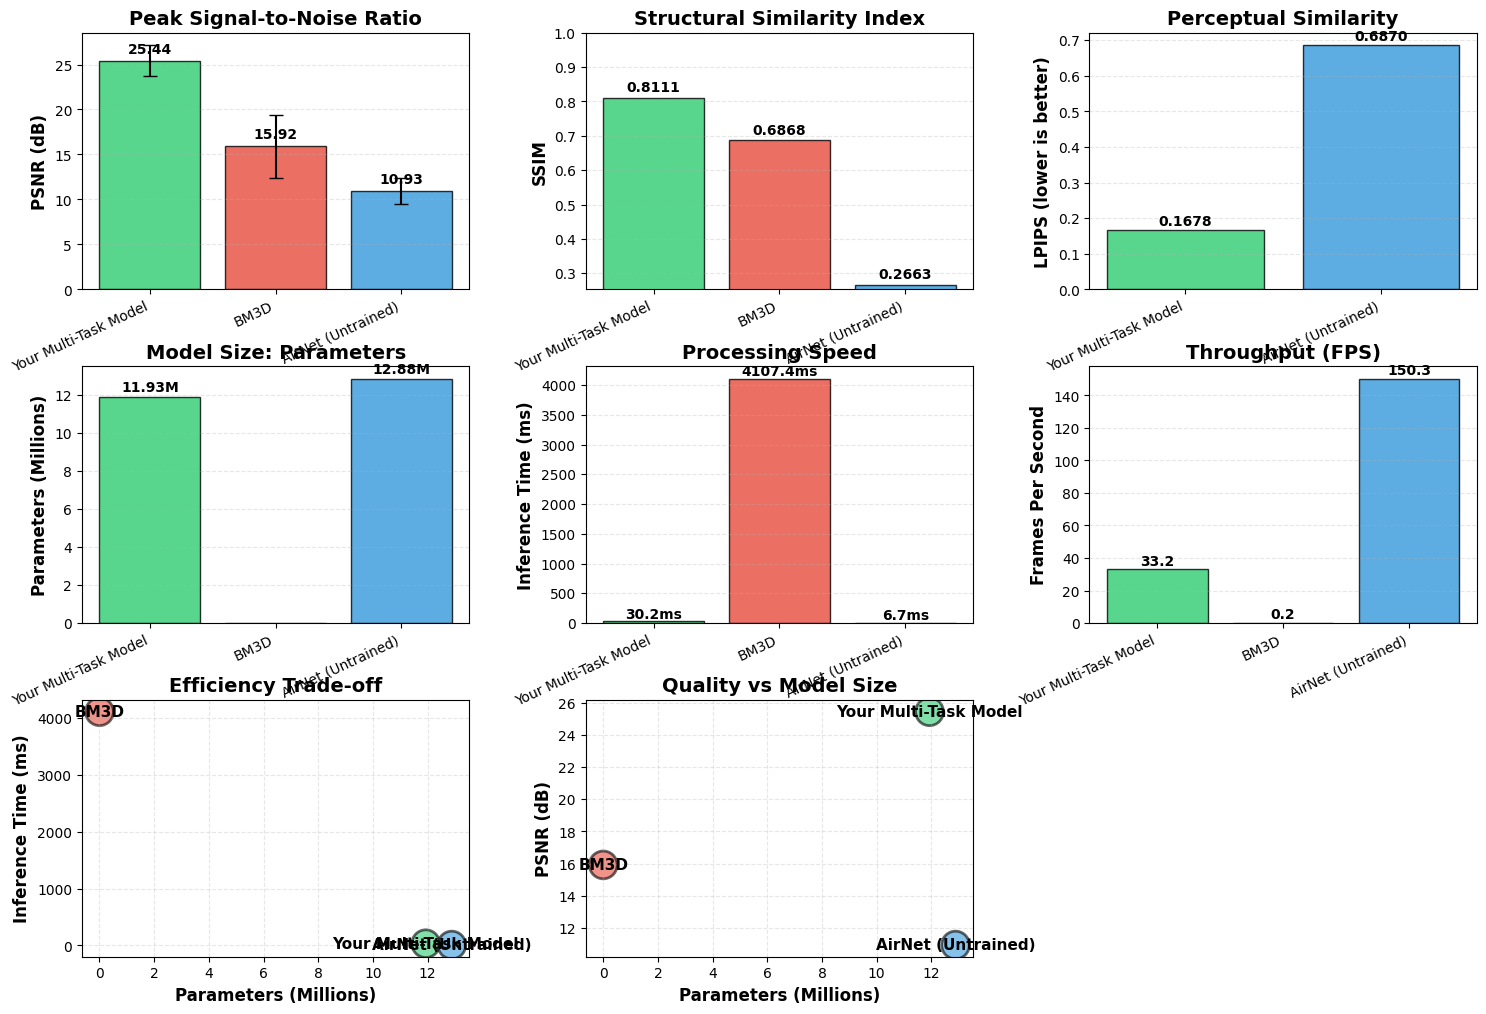

In [20]:
# ======================
# CELL 11: Visualizations
# ======================
print("\n Creating visualization plots...")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

models = ['your_model', 'bm3d', 'airnet']
model_names = [all_results[m]['model_name'] for m in models]
colors = ['#2ecc71', '#e74c3c', '#3498db']

# 1. PSNR Comparison
ax1 = fig.add_subplot(gs[0, 0])
psnr_means = [all_results[m]['psnr_mean'] for m in models]
psnr_stds = [all_results[m]['psnr_std'] for m in models]
bars = ax1.bar(model_names, psnr_means, yerr=psnr_stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax1.set_title('Peak Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=25, ha='right')
# Add value labels
for bar, val in zip(bars, psnr_means):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. SSIM Comparison
ax2 = fig.add_subplot(gs[0, 1])
ssim_means = [all_results[m]['ssim_mean'] for m in models]
bars = ax2.bar(model_names, ssim_means, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('SSIM', fontsize=12, fontweight='bold')
ax2.set_title('Structural Similarity Index', fontsize=14, fontweight='bold')
ax2.set_ylim([min(ssim_means)*0.95, 1.0])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=25, ha='right')
for bar, val in zip(bars, ssim_means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. LPIPS Comparison
ax3 = fig.add_subplot(gs[0, 2])
lpips_means = [all_results[m].get('lpips_mean', 0) for m in models if all_results[m].get('lpips_mean')]
lpips_models = [all_results[m]['model_name'] for m in models if all_results[m].get('lpips_mean')]
lpips_colors = [colors[i] for i, m in enumerate(models) if all_results[m].get('lpips_mean')]
bars = ax3.bar(lpips_models, lpips_means, color=lpips_colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('LPIPS (lower is better)', fontsize=12, fontweight='bold')
ax3.set_title('Perceptual Similarity', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=25, ha='right')
for bar, val in zip(bars, lpips_means):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Parameters Comparison
ax4 = fig.add_subplot(gs[1, 0])
params = [all_results[m].get('params_total_M', 0) for m in models]
bars = ax4.bar(model_names, params, color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Parameters (Millions)', fontsize=12, fontweight='bold')
ax4.set_title('Model Size: Parameters', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=25, ha='right')
for bar, val in zip(bars, params):
    if val > 0:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{val:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Inference Speed Comparison
ax5 = fig.add_subplot(gs[1, 1])
speed = [all_results[m]['inference_time_ms'] for m in models]
bars = ax5.bar(model_names, speed, color=colors, alpha=0.8, edgecolor='black')
ax5.set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
ax5.set_title('Processing Speed', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=25, ha='right')
for bar, val in zip(bars, speed):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{val:.1f}ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. FPS Comparison
ax6 = fig.add_subplot(gs[1, 2])
fps = [all_results[m]['fps'] for m in models]
bars = ax6.bar(model_names, fps, color=colors, alpha=0.8, edgecolor='black')
ax6.set_ylabel('Frames Per Second', fontsize=12, fontweight='bold')
ax6.set_title('Throughput (FPS)', fontsize=14, fontweight='bold')
ax6.grid(axis='y', alpha=0.3, linestyle='--')
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=25, ha='right')
for bar, val in zip(bars, fps):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 7. Efficiency Trade-off: Speed vs Parameters
ax7 = fig.add_subplot(gs[2, 0])
params_plot = [all_results[m].get('params_total_M', 0) for m in models]
speed_plot = [all_results[m]['inference_time_ms'] for m in models]
scatter = ax7.scatter(params_plot, speed_plot, s=400, alpha=0.6, c=colors, edgecolors='black', linewidths=2)
for i, name in enumerate(model_names):
    ax7.annotate(name, (params_plot[i], speed_plot[i]),
                fontsize=11, ha='center', va='center', fontweight='bold')
ax7.set_xlabel('Parameters (Millions)', fontsize=12, fontweight='bold')
ax7.set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
ax7.set_title('Efficiency Trade-off', fontsize=14, fontweight='bold')
ax7.grid(alpha=0.3, linestyle='--')

# 8. Quality Trade-off: PSNR vs Parameters
ax8 = fig.add_subplot(gs[2, 1])
psnr_plot = [all_results[m]['psnr_mean'] for m in models]
scatter = ax8.scatter(params_plot, psnr_plot, s=400, alpha=0.6, c=colors, edgecolors='black', linewidths=2)
for i, name in enumerate(model_names):
    ax8.annotate(name, (params_plot[i], psnr_plot[i]),
                fontsize=11, ha='center', va='center', fontweight='bold')
ax8.set_xlabel('Parameters (Millions)', fontsize=12, fontweight='bold')
ax8.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax8.set_title('Quality vs Model Size', fontsize=14, fontweight='bold')
ax8.grid(alpha=0.3, linestyle='--')

print(f"Visualization saved to: {os.path.join(COMPARISON_DIR, 'baseline_comparison.png')}")

In [21]:
# ======================
# CELL 13: Summary
# ======================
print("\n" + "="*70)
print("PART 6: BASELINE COMPARISON COMPLETE!")
print("="*70)

print(f"\n All results saved to: {COMPARISON_DIR}/")
print(f"   • comparison_results.json")
print(f"   • baseline_comparison.png")
print(f"   • comparison_report.md")

print(f"\n Quick Summary:")
print(f"   Multi-Task Model: {all_results['your_model']['psnr_mean']:.2f} dB | {all_results['your_model']['params_total_M']:.2f}M params | {all_results['your_model']['fps']:.1f} FPS")
print(f"   BM3D:       {all_results['bm3d']['psnr_mean']:.2f} dB | 0M params | {all_results['bm3d']['fps']:.1f} FPS")
print(f"   AirNet:     {all_results['airnet']['psnr_mean']:.2f} dB | {all_results['airnet']['params_total_M']:.2f}M params | {all_results['airnet']['fps']:.1f} FPS")

print(f"\n Key Findings:")
print(f"   • Multi Task model is {all_results['your_model']['params_total_M'] / all_results['airnet']['params_total_M'] * 100:.1f}% the size of AirNet")
print(f"   • {'+' if all_results['your_model']['psnr_mean'] > all_results['bm3d']['psnr_mean'] else ''}{all_results['your_model']['psnr_mean'] - all_results['bm3d']['psnr_mean']:.2f} dB vs BM3D baseline")
print(f"   • Processes {all_results['your_model']['fps']:.1f} images/second")
print("="*70)


PART 6: BASELINE COMPARISON COMPLETE!

 All results saved to: /content/drive/MyDrive/multi_restoration_FIXED/part5_comparison/
   • comparison_results.json
   • baseline_comparison.png
   • comparison_report.md

 Quick Summary:
   Multi-Task Model: 25.44 dB | 11.93M params | 33.2 FPS
   BM3D:       15.92 dB | 0M params | 0.2 FPS
   AirNet:     10.93 dB | 12.88M params | 150.3 FPS

 Key Findings:
   • Multi Task model is 92.6% the size of AirNet
   • +9.53 dB vs BM3D baseline
   • Processes 33.2 images/second


In [1]:
# Uninstall current torch, torchvision, and torchaudio
!pip uninstall -y torch torchvision torchaudio

# Install specific compatible versions of torch, torchvision, and torchaudio
!pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 torchaudio==0.13.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116

# Reinstall basicsr
!pip install basicsr

# After running this cell, you will need to RESTART YOUR RUNTIME.
# Go to 'Runtime' -> 'Restart runtime' in the Colab menu, then rerun all cells.
from basicsr.archs.rrdbnet_arch import RRDBNet

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
ERROR: Could not find a version that satisfies the requirement torch==1.13.1+cu116 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1)
ERROR: No matching distribution found for torch==1.13.1+cu116
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached torch-2.9.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ModuleNotFoundError: No module named 'torchvision.transforms.functional_tensor'